In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [25]:
def plot_nice_ddf(ddfs, rdf1, rdf2, ch1_name, ch2_name, dir_path):

    fig, axs = plt.subplots(2,2, figsize=(10,8))
    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)

    n, bins, _ = axs[0,0].hist(rdf1, bins=100, histtype='step', color='purple', orientation='horizontal')
    axs[0,0].text(0.3*np.max(n), 0.85*bins[-1], f'$\\sigma={round(np.std(rdf2), 2)}$ ppm', fontdict=dict(size=14))
    axs[0,0].set_xscale('log')
    axs[0,0].minorticks_on()
    axs[0,0].xaxis.tick_top()
    axs[0,0].set_ylabel(f'{ch2_name} rel. diff. (ppm)')

    h = axs[0,1].hist2d(rdf1, rdf2, bins=100, cmap='turbo', norm=LogNorm())
    axs[0,1].set_xticks([])
    axs[0,1].set_yticks([])
    pos = axs[0, 1].get_position()

    # Create a new axis for the colorbar
    cbar_ax = fig.add_axes([
        pos.x1 + 0.01,  # x: slightly to the right of axs[0,1]
        pos.y0,         # y: same bottom as axs[0,1]
        0.02,           # width of colorbar
        pos.height      # same height as axs[0,1]
    ])
    fig.colorbar(h[3], cax=cbar_ax)

    n, bins, _ = axs[1,0].hist(ddfs, bins=100, histtype='step', color='purple')
    # if np.std(ddf) >= 0.5:
    #     bin_centers = (bins[:-1] + 0.5*np.diff(bins))
    #     def mygaussian(x, N, sigma, mu):
    #         return N/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*(x-mu)*(x-mu)/(sigma*sigma))
    #     p0 = [np.sum(n), np.std(ddf), 0]
    #     popt_ddf, pcov = curve_fit(mygaussian, bin_centers, n, p0=p0)
    #     mygauss_domain = np.linspace(bin_centers[0], bin_centers[-1], 300)
    #     axs[1,0].plot(mygauss_domain, mygaussian(mygauss_domain, *popt_ddf), color='teal')
    # try:
    #     axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\sigma={round(popt_ddf[1], 2)}$ ppm', fontdict=dict(size=14))
    #     popt_ddf = None
    # except:
        # axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\sigma={round(np.std(ddf), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(ddfs), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,0].set_yscale('log')
    axs[1,0].minorticks_on()
    axs[1,0].set_xlabel(f'{ch1_name} - {ch2_name} ddf (ppm)')

    n, bins, _ = axs[1,1].hist(rdf2, bins=100, histtype='step', color='purple')
    axs[1,1].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(rdf2), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,1].set_yscale('log')
    axs[1,1].minorticks_on()
    axs[1,1].yaxis.tick_right()
    axs[1,1].set_xlabel(f'{ch2_name} rel. diff (ppm)')

    # fig.savefig(dir_path + 'ddf_plot')
    
    return

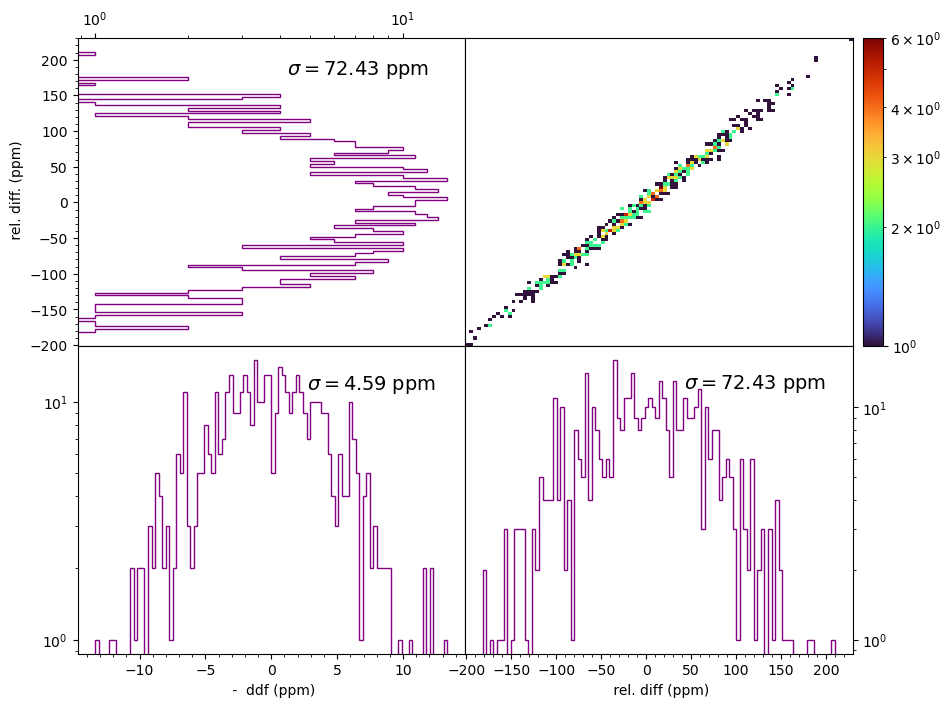

In [26]:
data = np.load(r'/home/cameron/Desktop/research/rfsoc_analysis/data/ddfs_rdfs_500pairs_12dBm_CDIQ.npz')

ddfs = data['ddfs']
rdf1, rdf2 = data['rdfs'][0,:], data['rdfs'][1,:]

mask = np.abs(ddfs) < 1e-3
mask = (np.abs(ddfs) < 1e-3) & (np.abs(rdf1) < 1400e-6)
ddfs = ddfs[mask]
rdf1 = rdf1[mask]
rdf2 = rdf2[mask]

ddfs, rdf1, rdf2 = ddfs*1e6, rdf1*1e6, rdf2*1e6

plot_nice_ddf(ddfs, rdf1, rdf2, '', '', '')